# DECISION TREE

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

- Loading the data

In [12]:
df = pd.read_csv("../data/processed/final_spotify.csv", encoding='latin-1')
df.head(3)

,Track,Artist,Genre,Release Date,All Time Rank,Spotify Streams,Spotify Popularity,YouTube Views,TikTok Views,AirPlay Spins,Shazam Counts,Explicit Track,Isrc,Spotify_id,Acousticness,Danceability,Duration_ms,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Time_signature,Valence
0,Million Dollar Baby,Tommy Richman,Latin,4/26/2024,1,390470936,92,84274754,5332281936,40975,2669262,0,QM24S2402528,5AJ9hqTS2wcFQCELCFRO7A,0.097300,0.852,155152.0,0.697,0.00037,1.0,0.0678,-5.520,0.0,0.0439,138.029,4.0,0.919
1,Not Like Us,Kendrick Lamar,R&B/Soul,5/4/2024,2,323703884,92,116347040,208339025,40778,1118279,1,USUG12400910,6AI3ezQ4o3HUoP6Dhudph3,0.010700,0.898,274192.0,0.472,0.00000,1.0,0.1410,-7.001,1.0,0.0776,101.061,4.0,0.214
2,I Like The Way You Kiss Me,Artemas,Pop,3/19/2024,3,601309283,92,122599116,3369120610,74333,5285340,0,QZJ842400387,2GxrNKugF82CnoRFbQfzPf,0.000938,0.599,142515.0,0.946,0.01060,11.0,0.0826,-4.263,1.0,0.0447,151.647,4.0,0.747


In [13]:
# Create artist popularity feature
df["artist_track_count"] = df.groupby("Artist")["Track"].transform("count")

# Create target: top 25% Spotify Popularity = popular
threshold = df["Spotify Popularity"].quantile(0.75)
df["is_popular"] = (df["Spotify Popularity"] >= threshold).astype(int)

# Check the balance
print("Target distribution:")
print(df["is_popular"].value_counts())
print(f"\nThreshold: Spotify Popularity >= {threshold} = Popular")

Target distribution:
is_popular
0    1957
1     770
Name: count, dtype: int64

Threshold: Spotify Popularity >= 73.0 = Popular


In [20]:
feature_cols = [
    # Audio features (how the song SOUNDS)
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration_ms", "Key", "Mode",
    # Cross-platform features (where the song LIVES)
    # No Spotify Streams — too correlated with target = data leakage
    "YouTube Views",
    "TikTok Views",
    "Shazam Counts",
    # Artist feature
    "artist_track_count"
]

In [21]:
# Drop rows with missing values in our features
df_clean = df[feature_cols + ["is_popular"]].dropna()
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Rows before cleaning: 2727
Rows after cleaning: 2727
Rows dropped: 0


In [7]:
dt = DecisionTreeClassifier(
    max_depth=4,        # limit to 4 levels of questions
    random_state=42     # makes results reproducible (same result every time)
)

In [22]:
X = df_clean[feature_cols]
y = df_clean["is_popular"]

# 80% for training, 20% for testing
# random_state=42 ensures same split every time you run
# stratify=y ensures both sets have same proportion of popular/not popular
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} songs")
print(f"Test set: {len(X_test)} songs")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 2181 songs
Test set: 546 songs

Training target distribution:
is_popular
0    1565
1     616
Name: count, dtype: int64

Test target distribution:
is_popular
0    392
1    154
Name: count, dtype: int64


In [23]:
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)

In [25]:
X_test_scaled = scaler.transform(X_test)

In [26]:
print("Scaling done!")
print(f"Example — before: YouTube Views mean = {X_train['YouTube Views'].mean():.0f}")
print(f"Example — after: YouTube Views mean = {X_train_scaled[:, feature_cols.index('YouTube Views')].mean():.2f}")

Scaling done!
Example — before: YouTube Views mean = 474523382
Example — after: YouTube Views mean = 0.00


In [27]:
dt_default = DecisionTreeClassifier(
    max_depth=4,        # 4 levels of questions
    random_state=42     # reproducible results
)

dt_default.fit(X_train_scaled, y_train)
y_pred_dt_default = dt_default.predict(X_test_scaled)

print("=== DECISION TREE (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt_default, target_names=["Not Popular", "Popular"]))

=== DECISION TREE (default) ===
Accuracy: 0.747

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.76      0.94      0.84       392
     Popular       0.63      0.25      0.36       154

    accuracy                           0.75       546
   macro avg       0.70      0.60      0.60       546
weighted avg       0.72      0.75      0.71       546



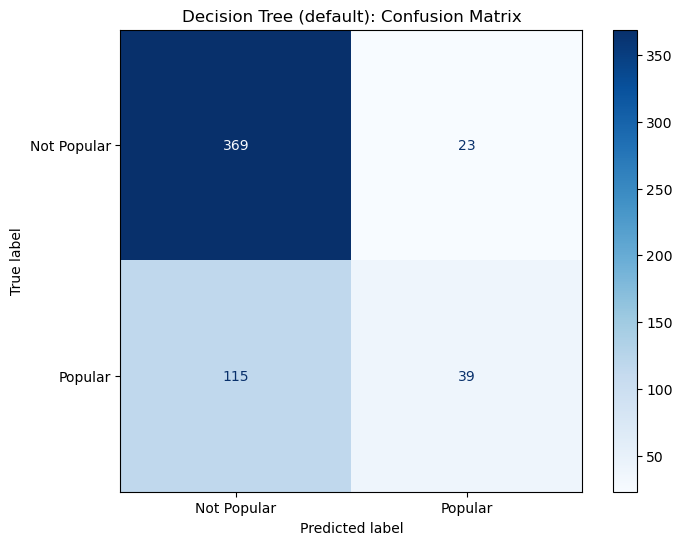

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dt_default, X_test_scaled, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Blues", ax=ax
)
plt.title("Decision Tree (default): Confusion Matrix")
plt.show()

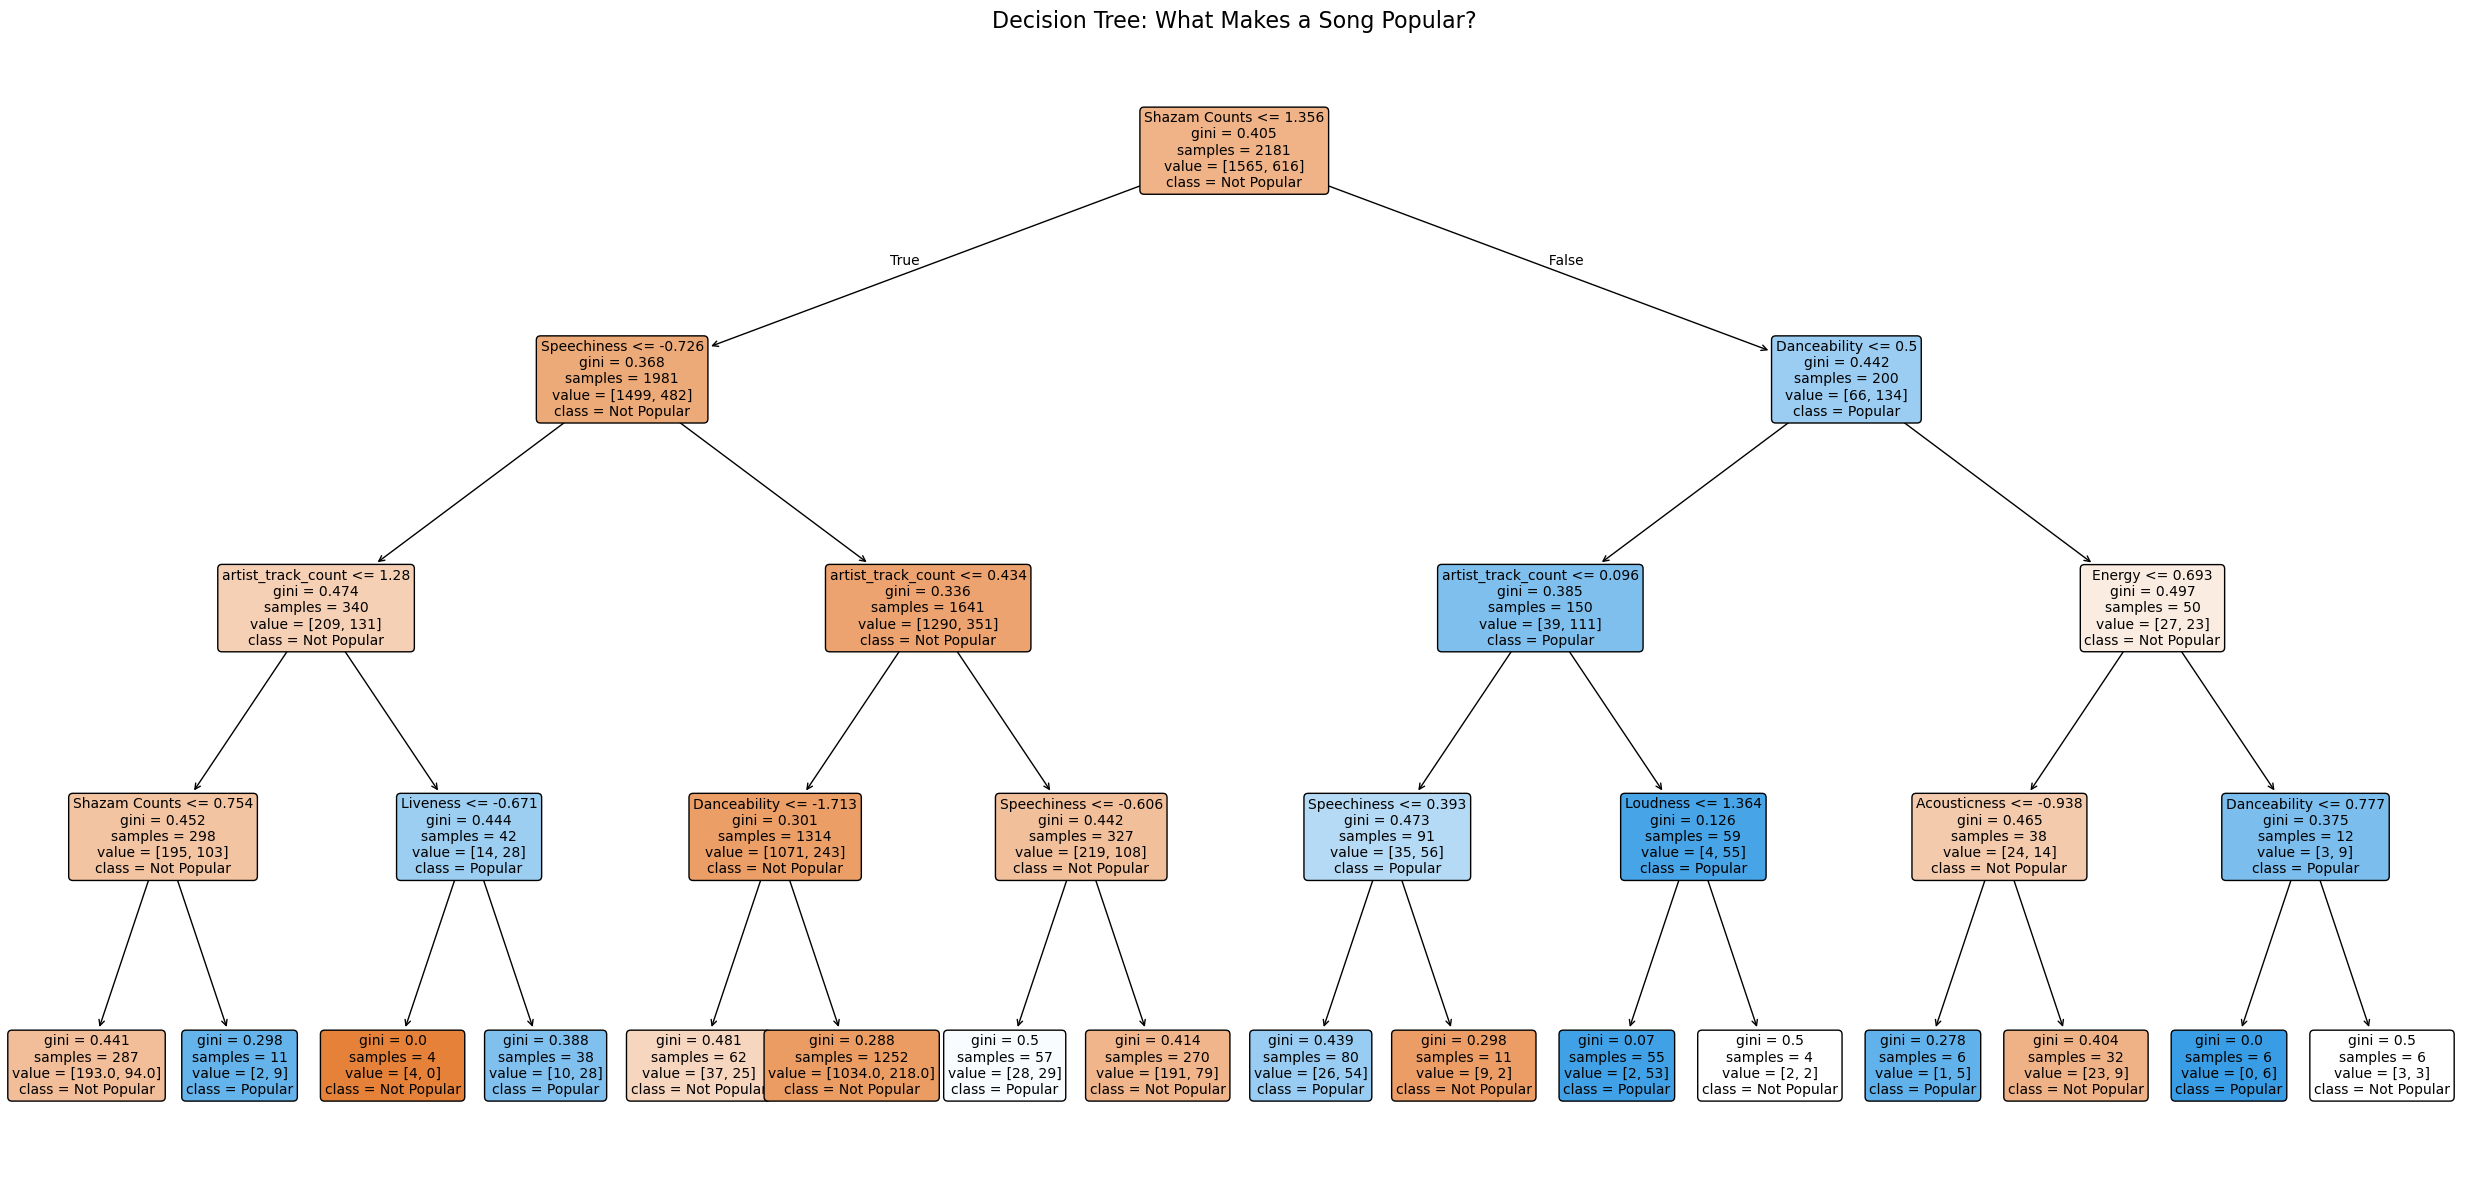

In [30]:
plt.figure(figsize=(25, 12))
plot_tree(
    dt_default,
    feature_names=feature_cols,
    class_names=["Not Popular", "Popular"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree: What Makes a Song Popular?", fontsize=16)
plt.tight_layout()
plt.show()

Breaking Down Your Decision Tree 🎵
What is a decision tree?
It's a model that asks cascading questions (like a game of 20 questions) to classify a song as Popular or Not Popular. At each node, it splits the data based on the most useful feature.

What's inside each box
FieldMeaningcondition (e.g. Shazam Counts <= 1.356)The question asked at this nodeginiNode impurity — 0 = pure (one class only), 0.5 = perfectly mixedsamplesNumber of songs reaching this nodevalue = [X, Y]X = Not Popular songs, Y = Popular songsclassThe majority prediction at this node

How your tree works
🔝 Root — The most important question

Shazam Counts <= 1.356

This is the feature that best separates the data. Out of 2181 songs:

True (left) → 1981 songs — mostly Not Popular
False (right) → 200 songs — mostly Popular

➡️ Key insight: having a high Shazam count is the #1 signal of popularity.

🌿 Left branch (few Shazams → probably Not Popular)
The model refines with:

Speechiness — too much spoken word = less popular
Artist track count — artists with fewer tracks in the dataset
Danceability, Liveness — secondary audio features

🌿 Right branch (many Shazams → probably Popular)
The model refines with:

Danceability <= 0.5 — highly danceable songs stay popular
Artist track count — prolific artists
Energy, Acousticness — sound characteristics


The leaves (final decisions)
The boxes at the very bottom are the final predictions:

🟠 Orange = Not Popular
🔵 Blue = Popular

The purest node in the tree: gini = 0.0, value = [4, 0] → 4 songs, 100% Not Popular, zero mistakes.

Most important features summary
RankFeatureRole1Shazam CountsMain deciding factor2SpeechinessFilters out overly "spoken" tracks3Artist track countEstablished vs emerging artists4DanceabilityBoosts popularity5Energy / AcousticnessFinal fine-tuning

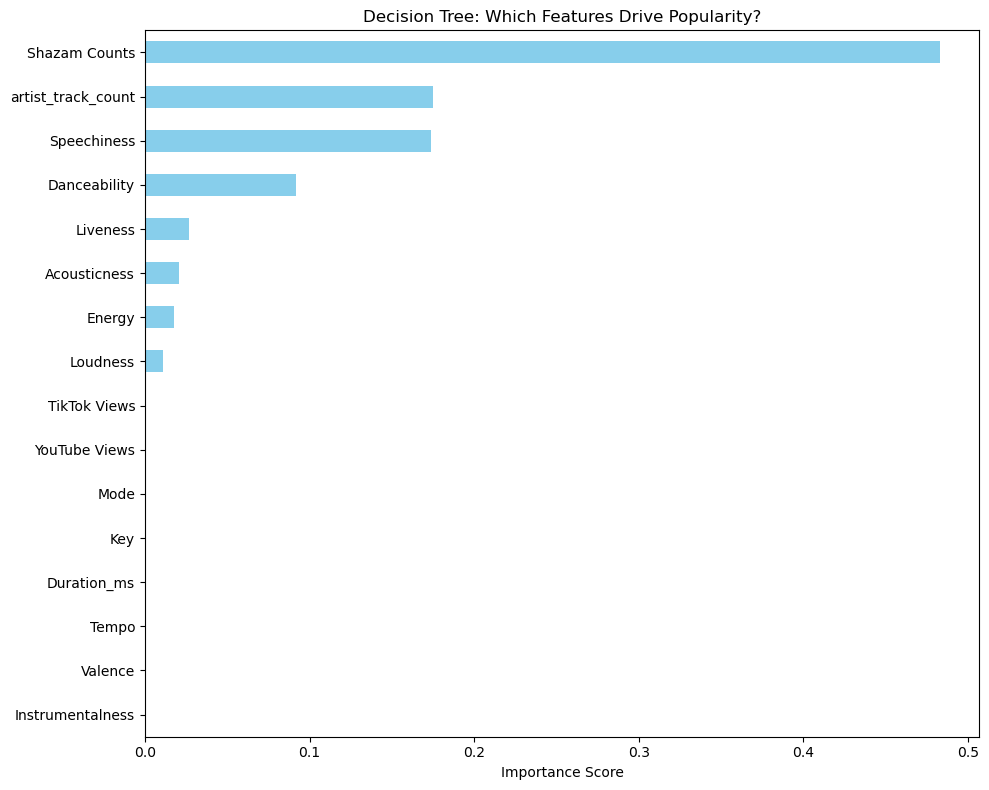


Top 5 most important features:
Shazam Counts         0.482757
artist_track_count    0.175056
Speechiness           0.173808
Danceability          0.092025
Liveness              0.026627
dtype: float64


In [31]:
importance_dt = pd.Series(
    dt_default.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(10, 8))
importance_dt.plot(kind="barh", color="skyblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree: Which Features Drive Popularity?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_dt.sort_values(ascending=False).head())

In [32]:
train_acc_dt = accuracy_score(y_train, dt_default.predict(X_train_scaled))
test_acc_dt = accuracy_score(y_test, y_pred_dt_default)

print(f"Train accuracy: {train_acc_dt:.3f}")
print(f"Test accuracy:  {test_acc_dt:.3f}")
print(f"Gap:            {train_acc_dt - test_acc_dt:.3f}")

if train_acc_dt - test_acc_dt > 0.10:
    print("⚠️ Possible overfitting — tuning should help")
else:
    print("✅ No major overfitting")

Train accuracy: 0.770
Test accuracy:  0.747
Gap:            0.023
✅ No major overfitting


In [34]:
param_grid_dt = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best F1 (cross-validated): {grid_dt.best_score_:.3f}")

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 (cross-validated): 0.421


In [35]:
best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_scaled)

print("=== DECISION TREE (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_dt):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt,
                            target_names=["Not Popular", "Popular"]))

# Compare with default
print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_dt):.3f}")

=== DECISION TREE (tuned) ===
Accuracy: 0.734

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.77      0.89      0.83       392
     Popular       0.55      0.34      0.42       154

    accuracy                           0.73       546
   macro avg       0.66      0.61      0.62       546
weighted avg       0.71      0.73      0.71       546


--- Improvement ---
Default accuracy: 0.747
Tuned accuracy:   0.734


# XG BOOST

In [36]:
xgb_default = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_default.fit(X_train_scaled, y_train)
y_pred_xgb_default = xgb_default.predict(X_test_scaled)

print("=== XGBOOST (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_default,
                            target_names=["Not Popular", "Popular"]))

=== XGBOOST (default) ===
Accuracy: 0.762

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.78      0.92      0.85       392
     Popular       0.64      0.35      0.45       154

    accuracy                           0.76       546
   macro avg       0.71      0.64      0.65       546
weighted avg       0.74      0.76      0.74       546



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:27:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


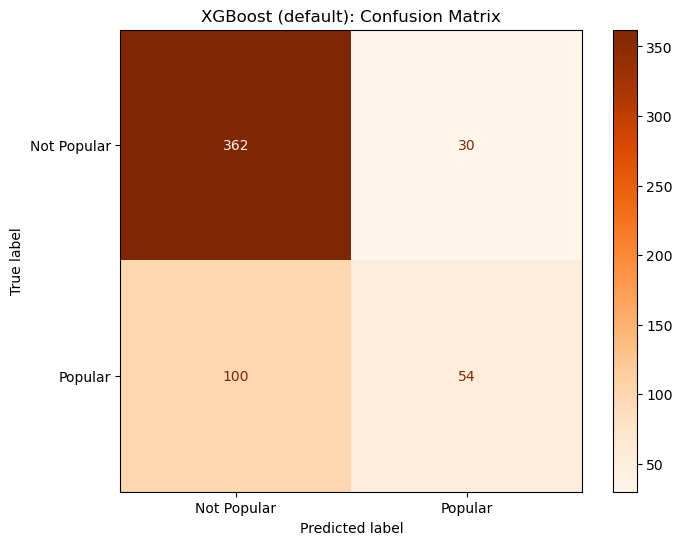

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    xgb_default, X_test_scaled, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Oranges", ax=ax
)
plt.title("XGBoost (default): Confusion Matrix")
plt.show()

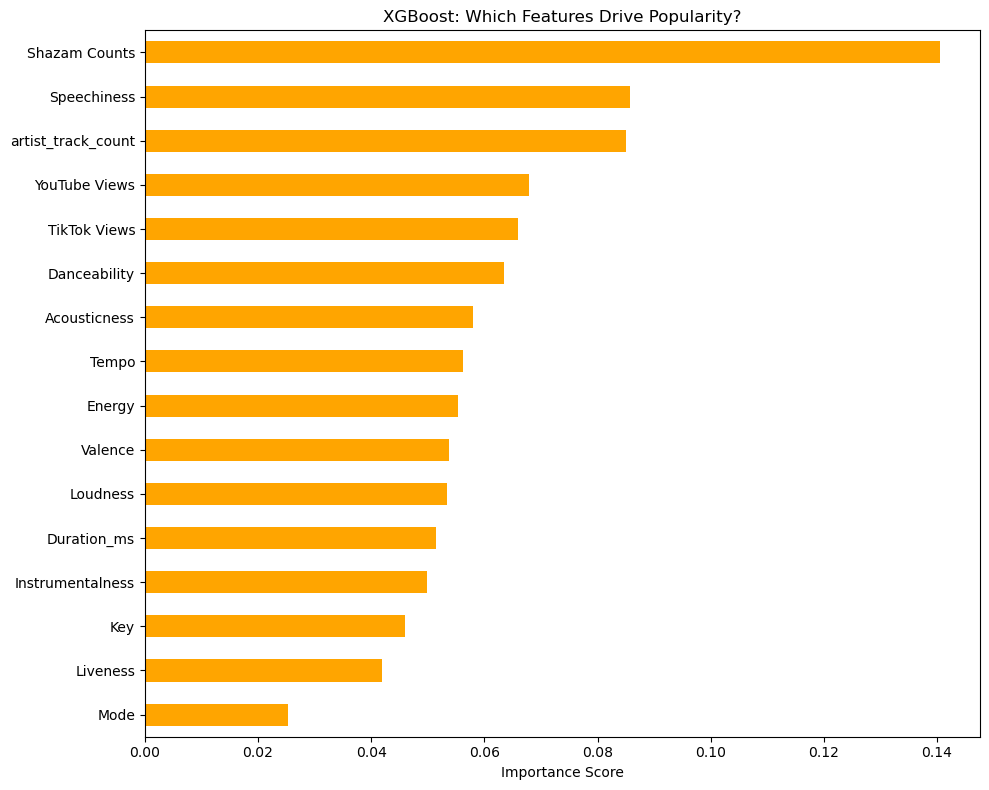


Top 5 most important features:
Shazam Counts         0.140571
Speechiness           0.085751
artist_track_count    0.085049
YouTube Views         0.067937
TikTok Views          0.065893
dtype: float32


In [38]:
importance_xgb = pd.Series(
    xgb_default.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(10, 8))
importance_xgb.plot(kind="barh", color="orange")
plt.xlabel("Importance Score")
plt.title("XGBoost: Which Features Drive Popularity?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_xgb.sort_values(ascending=False).head())

In [39]:
train_acc_xgb = accuracy_score(y_train, xgb_default.predict(X_train_scaled))
test_acc_xgb = accuracy_score(y_test, y_pred_xgb_default)

print(f"Train accuracy: {train_acc_xgb:.3f}")
print(f"Test accuracy:  {test_acc_xgb:.3f}")
print(f"Gap:            {train_acc_xgb - test_acc_xgb:.3f}")

if train_acc_xgb - test_acc_xgb > 0.10:
    print("⚠️ Possible overfitting — tuning should help")
else:
    print("✅ No major overfitting")

Train accuracy: 0.889
Test accuracy:  0.762
Gap:            0.127
⚠️ Possible overfitting — tuning should help


In [40]:
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),
    param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best F1 (cross-validated): {grid_xgb.best_score_:.3f}")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:27:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:27:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:27:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:27:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best F1 (cross-validated): 0.449


In [41]:
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print("=== XGBOOST (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb,
                            target_names=["Not Popular", "Popular"]))

print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_xgb):.3f}")

=== XGBOOST (tuned) ===
Accuracy: 0.760

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.79      0.91      0.84       392
     Popular       0.62      0.38      0.47       154

    accuracy                           0.76       546
   macro avg       0.71      0.64      0.66       546
weighted avg       0.74      0.76      0.74       546


--- Improvement ---
Default accuracy: 0.762
Tuned accuracy:   0.760


In [42]:
y_proba = best_xgb.predict_proba(X_test_scaled)

# Show confidence levels
df_predictions = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_best_xgb,
    "confidence": y_proba[:, 1]  # probability of being popular
})

print("Most confident POPULAR predictions:")
print(df_predictions[df_predictions["predicted"] == 1]
      .sort_values("confidence", ascending=False).head(10))

print("\nBorderline predictions (model was unsure):")
print(df_predictions.sort_values("confidence",
      key=lambda x: abs(x - 0.5)).head(10))

Most confident POPULAR predictions:
     actual  predicted  confidence
506       1          1    0.977691
63        1          1    0.971165
408       1          1    0.970734
1         1          1    0.967041
362       0          1    0.966010
480       1          1    0.949908
416       1          1    0.949908
414       1          1    0.915243
285       1          1    0.898971
454       1          1    0.894775

Borderline predictions (model was unsure):
     actual  predicted  confidence
303       0          0    0.499695
465       0          1    0.502818
528       0          1    0.503183
12        0          1    0.505763
52        1          0    0.494203
151       0          0    0.485375
70        1          0    0.485049
444       1          1    0.515666
373       0          0    0.483617
302       0          0    0.482543
